# FPGA Ring Oscillator TRNG — Full Randomness Analysis
### NIST SP 800-22 Rev 1a · SP 800-90B Min-Entropy · Dieharder-style Extra Tests

**Hardware:** Artix-7 FPGA, ring oscillator entropy source + fingerprint seed  
**Reference:** Rukhin et al. (2010), NIST SP 800-22 Rev 1a; NIST SP 800-90B  
**Significance level:** α = 0.01 (p-value threshold for pass/fail)

---


## 0 · Setup

In [1]:
# Install dependencies if needed
# !pip install numpy scipy matplotlib

import math, time, warnings, collections, struct
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from scipy.special import erfc, gammainc, hyp1f1

warnings.filterwarnings("ignore")

# ── Plot style ───────────────────────────────────────────────────────────────
PASS_COLOR = "#3B6D11"; FAIL_COLOR = "#A32D2D"
PASS_BG    = "#EAF3DE"; FAIL_BG    = "#FCEBEB"
ACCENT     = "#185FA5"; TEAL       = "#0F6E56"
MUTED      = "#888780"; PURPLE     = "#534AB7"
AMBER      = "#BA7517"; CORAL      = "#993C1D"

plt.rcParams.update({
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#D3D1C7",
    "grid.linewidth":    0.5,
    "grid.alpha":        0.7,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})
print("Setup complete.")


Setup complete.


## 1 · Load data

Set `CSV_PATH` to the path of your `random_values_everything.csv` file.  
The CSV must have the header: `Index,HexValue,DecimalValue,Timestamp`


In [2]:
CSV_PATH = "random_values_v3.csv"   # <-- change this if needed
SKIP_LINEAR_COMPLEXITY = False   # set True to skip the slowest test (~45-90 min at 800k samples)

# ── Parse CSV ────────────────────────────────────────────────────────────────
# Handles three known encoding variants from this sensor/logger:
#   1. Plain UTF-8 with UTF-8 BOM              (original dataset)
#   2. UTF-16 LE with UTF-8 BOM header +       (ojas dataset)
#      UTF-16 LE data rows (null byte padding)
#   3. Excel scientific-notation hex mangling  (e.g. "3.00E+08")
t0 = time.time()

def _read_csv_lines(path):
    """Return clean CSV lines regardless of encoding variant."""
    with open(path, "rb") as f:
        raw = f.read()
    # Decode stripping UTF-8 BOM if present
    text = raw.decode("utf-8-sig", errors="replace")
    lines = text.splitlines()
    # If data lines contain null bytes, the body is UTF-16 LE embedded in UTF-8.
    # Strip all null bytes — they are purely an encoding artefact.
    if any(chr(0) in l for l in lines[1:4]):
        lines = [l.replace(chr(0), "") for l in lines]
    return [l for l in lines if l.strip()]

def parse_hex(raw):
    """Return a clean uppercase hex string, or None if unparseable."""
    raw = raw.strip().upper()
    if all(c in "0123456789ABCDEF" for c in raw):
        return raw.lstrip("0") or "0"
    # Excel scientific notation mangling e.g. "3.00E+08", "8.00E+03"
    try:
        val = int(round(float(raw)))
        if 0 <= val <= 65535:
            return hex(val)[2:].upper().lstrip("0") or "0"
        return None          # out-of-range → fall back to decimal column
    except (ValueError, OverflowError):
        return None

hex_values, dec_values = [], []
skipped = 0

for line in _read_csv_lines(CSV_PATH):
    if line.lower().startswith("index"):
        continue
    parts = line.split(",")
    if len(parts) < 3:
        skipped += 1
        continue

    hex_str = parse_hex(parts[1])
    try:
        dec_val = int(round(float(parts[2].strip())))
    except (ValueError, OverflowError):
        skipped += 1
        continue

    if hex_str is None:
        # Hex column corrupted — reconstruct from decimal value
        if 0 <= dec_val <= 65535:
            hex_str = hex(dec_val)[2:].upper().lstrip("0") or "0"
        else:
            skipped += 1
            continue

    hex_values.append(hex_str)
    dec_values.append(dec_val)

if skipped:
    print(f"  Warning: skipped {skipped} truly malformed rows")

# uint32 during processing, clip + cast to uint16 at end
dec_values = np.array(dec_values, dtype=np.uint32)
out_of_range = int(np.sum(dec_values > 65535))
if out_of_range:
    print(f"  Warning: {out_of_range} values clamped to 65535")
    dec_values = np.clip(dec_values, 0, 65535)
dec_values = dec_values.astype(np.uint16)

# ── Convert to bit array (16 bits per sample) ────────────────────────────────
bits_list = []
for h in hex_values:
    n = int(h, 16)
    for i in range(15, -1, -1):
        bits_list.append((n >> i) & 1)

bits      = np.array(bits_list, dtype=np.int8)
n_samples = len(dec_values)
n_bits    = len(bits)
byte_values = dec_values.copy()

print(f"Loaded {n_samples:,} samples  →  {n_bits:,} bits  ({time.time()-t0:.2f}s)")
print(f"Bit-1 proportion: {np.mean(bits):.6f}  (ideal: 0.5)")
print(f"Value range: {int(dec_values.min())}–{int(dec_values.max())}  (expected 0–65535)")


Loaded 537,850 samples  →  8,605,600 bits  (6.39s)
Bit-1 proportion: 0.500697  (ideal: 0.5)
Value range: 0–65535  (expected 0–65535)


## 2 · Test helpers

In [3]:
def pm(b):
    return 2 * b.astype(np.float64) - 1

results = []   # collects all test result dicts

def run_test(label, fn):
    print(f"  {label}", end="", flush=True)
    t0 = time.time()
    r  = fn()
    r["elapsed_ms"] = round((time.time() - t0) * 1000, 1)
    status = "PASS ✓" if r["passed"] else "FAIL ✗"
    print(f"  {status}   p = {r['p_value']:.6f}   ({r['elapsed_ms']:.0f} ms)")
    results.append(r)
    return r

print("Helpers ready.")


Helpers ready.


## 3 · Test 1 — Monobit Frequency
**NIST SP 800-22 §2.1**

Verifies that 1s and 0s occur with equal probability across the entire bitstream.  
A biased ring oscillator (asymmetric inverter delays) will fail this immediately.


In [4]:
def test_monobit():
    S     = np.sum(pm(bits))
    s_obs = abs(S) / math.sqrt(n_bits)
    p     = float(erfc(s_obs / math.sqrt(2)))
    ones  = int(np.sum(bits))
    return dict(name="Monobit Frequency", p_value=p, passed=p >= 0.01,
                ones=ones, zeros=n_bits - ones,
                ratio=ones / n_bits, s_obs=s_obs)

r_monobit = run_test("Monobit Frequency     ", test_monobit)
print(f"  Ones: {r_monobit['ones']:,}  Zeros: {r_monobit['zeros']:,}  Ratio: {r_monobit['ratio']:.6f}")


  Monobit Frequency       FAIL ✗   p = 0.000043   (143 ms)
  Ones: 4,308,802  Zeros: 4,296,798  Ratio: 0.500697


## 4 · Test 2 — Block Frequency
**NIST SP 800-22 §2.2**

Divides the bitstream into M-bit blocks and tests whether the proportion of ones  
in each block is close to 0.5. Catches local bias that the monobit test can miss  
if bias zones are symmetric across the full stream.


In [5]:
def test_block_frequency(M=128):
    N      = n_bits // M
    blocks = bits[:N * M].reshape(N, M)
    pi_i   = blocks.mean(axis=1)
    chi_sq = 4 * M * float(np.sum((pi_i - 0.5) ** 2))
    p      = float(1 - gammainc(N / 2, chi_sq / 2))
    return dict(name="Block Frequency", p_value=p, passed=p >= 0.01,
                M=M, N=N, chi_sq=chi_sq, pi_blocks=pi_i)

r_block = run_test("Block Frequency       ", test_block_frequency)
print(f"  Blocks: {r_block['N']:,}   Block size M={r_block['M']}   χ²={r_block['chi_sq']:.4f}")


  Block Frequency         PASS ✓   p = 0.775455   (16 ms)
  Blocks: 67,231   Block size M=128   χ²=66953.1562


## 5 · Test 3 — Runs
**NIST SP 800-22 §2.3**

Checks whether the number of uninterrupted sequences of identical bits matches a random source.  
Ring oscillators can exhibit short-range correlation due to jitter autocorrelation — this catches it.


In [6]:
def test_runs():
    pi = float(np.mean(bits))
    if abs(pi - 0.5) >= 2 / math.sqrt(n_bits):
        return dict(name="Runs", p_value=0.0, passed=False,
                    note="Pre-condition failed", pi=pi)
    V   = 1 + int(np.sum(bits[:-1] != bits[1:]))
    num = abs(V - 2 * n_bits * pi * (1 - pi))
    den = 2 * math.sqrt(2 * n_bits) * pi * (1 - pi)
    p   = float(erfc(num / den))
    return dict(name="Runs", p_value=p, passed=p >= 0.01,
                runs_observed=V,
                runs_expected=round(2 * n_bits * pi * (1 - pi), 1),
                pi=pi)

r_runs = run_test("Runs                  ", test_runs)
print(f"  Runs observed: {r_runs.get('runs_observed','N/A')}  Expected: {r_runs.get('runs_expected','N/A')}")


  Runs                    FAIL ✗   p = 0.000000   (13 ms)
  Runs observed: N/A  Expected: N/A


## 6 · Test 4 — Longest Run of Ones in a Block
**NIST SP 800-22 §2.4**

Examines the longest run of ones in 128-bit blocks and compares to the expected  
distribution. Catches pathological cases where the oscillator gets "stuck" high.


In [7]:
def test_longest_run(M=128):
    N      = n_bits // M
    blocks = bits[:N * M].reshape(N, M)
    nu     = np.zeros(7, dtype=int)   # buckets: ≤1,2,3,4,5,6,≥7 for M=128
    for block in blocks:
        # find longest run of ones
        longest = 0; cur = 0
        for b in block:
            if b: cur += 1; longest = max(longest, cur)
            else: cur = 0
        idx = min(max(longest - 1, 0), 6)
        nu[idx] += 1
    # Reference probabilities for M=128 from SP 800-22 Table 1
    pi = np.array([0.1174, 0.2430, 0.2493, 0.1752, 0.1027, 0.1124, 0.0000])
    # Last bucket absorbs ≥7 — redistribute tail
    pi = np.array([0.0882, 0.2092, 0.2483, 0.1933, 0.1208, 0.0675, 0.0727])
    chi_sq = float(np.sum((nu - N * pi) ** 2 / (N * pi + 1e-12)))
    p      = float(1 - gammainc(3, chi_sq / 2))
    return dict(name="Longest Run", p_value=p, passed=p >= 0.01,
                M=M, N=N, nu=nu.tolist(), chi_sq=chi_sq)

r_longestrun = run_test("Longest Run           ", test_longest_run)
print(f"  χ² = {r_longestrun['chi_sq']:.4f}   Blocks = {r_longestrun['N']:,}")


  Longest Run             FAIL ✗   p = 0.000000   (1574 ms)
  χ² = 171700.6354   Blocks = 67,231


## 7 · Test 5 — Spectral (FFT)
**NIST SP 800-22 §2.6**

Uses FFT to detect periodic structure in the bitstream.  
Ring oscillator jitter can have periodic components from power supply noise, clock coupling, or EMI.  
This is the test most specific to ring oscillator failure modes — runs in O(n log n).


In [8]:
def test_spectral():
    x    = pm(bits)
    f    = np.fft.fft(x)
    mags = np.abs(f[: n_bits // 2])
    T    = math.sqrt(math.log(1 / 0.05) * n_bits)
    N0   = 0.95 * n_bits / 2
    N1   = float(np.sum(mags < T))
    d    = (N1 - N0) / math.sqrt(n_bits * 0.95 * 0.05 / 4)
    p    = float(erfc(abs(d) / math.sqrt(2)))
    return dict(name="Spectral (FFT)", p_value=p, passed=p >= 0.01,
                N0=N0, N1=N1, d=d, magnitudes=mags, threshold=T)

r_spectral = run_test("Spectral (FFT)        ", test_spectral)
print(f"  N0 (expected below threshold): {r_spectral['N0']:.1f}")
print(f"  N1 (observed below threshold): {r_spectral['N1']:.1f}")


  Spectral (FFT)          FAIL ✗   p = 0.000000   (3090 ms)
  N0 (expected below threshold): 4087660.0
  N1 (observed below threshold): 4038425.0


## 8 · Test 6 — Non-overlapping Template Matching
**NIST SP 800-22 §2.7**

Counts occurrences of a specific aperiodic m-bit pattern in 8 sub-blocks.  
Tests a representative set of 10 patterns of length m=9 (full NIST run uses 148).  
Detects if specific bit patterns appear too often or too rarely.


In [9]:
def test_non_overlapping_template(template):
    M = 1032   # block length per NIST recommendation for m=9
    N = n_bits // M
    m = len(template)
    mu    = (M - m + 1) / 2**m
    sigma = math.sqrt(M * (1/2**m - (2*m-1)/2**(2*m)))
    W     = np.zeros(N, dtype=float)
    for j in range(N):
        block = bits[j*M:(j+1)*M]
        count = 0; i = 0
        while i <= M - m:
            if np.array_equal(block[i:i+m], template):
                count += 1; i += m
            else:
                i += 1
        W[j] = count
    chi_sq = float(np.sum((W - mu)**2 / sigma**2))
    p = float(1 - gammainc(N/2, chi_sq/2))
    return p >= 0.01, p

# Test 10 representative aperiodic 9-bit templates
templates_9 = [
    [0,0,0,0,0,1,0,0,1],
    [1,1,1,0,1,1,0,1,1],
    [0,1,0,1,1,0,0,1,0],
    [1,0,1,1,0,0,1,0,1],
    [0,0,1,0,0,0,1,0,1],
    [1,0,0,1,1,0,1,1,0],
    [0,1,1,0,0,1,0,0,0],
    [1,1,0,1,0,0,0,1,1],
    [0,0,0,1,0,1,1,0,0],
    [1,1,1,0,0,1,1,0,1],
]
t0_now = time.time()
print("  Running 10 non-overlapping template tests (m=9)...", flush=True)
not_results = []
for tmpl in templates_9:
    passed, pv = test_non_overlapping_template(np.array(tmpl, dtype=np.int8))
    not_results.append((passed, pv))

pass_count = sum(1 for p,_ in not_results if p)
min_p      = min(pv for _,pv in not_results)
max_p      = max(pv for _,pv in not_results)
# Use minimum p-value as the summary score (conservative)
r_not = dict(name="Non-overlapping Tmpl", p_value=min_p,
             passed=pass_count >= 9,   # allow 1 failure from random chance
             pass_count=pass_count, total=10,
             all_p=[pv for _,pv in not_results],
             elapsed_ms=round((time.time()-t0_now)*1000,1))
results.append(r_not)
status = "PASS ✓" if r_not["passed"] else "FAIL ✗"
print(f"  Non-overlapping Tmpl  {status}   {pass_count}/10 templates pass   "
      f"min_p={min_p:.6f}   ({r_not['elapsed_ms']:.0f} ms)")


  Running 10 non-overlapping template tests (m=9)...
  Non-overlapping Tmpl  PASS ✓   10/10 templates pass   min_p=0.077751   (961892 ms)


## 9 · Test 7 — Approximate Entropy
**NIST SP 800-22 §2.12**

Measures the entropy rate per bit by comparing overlapping m-bit pattern frequencies  
for two consecutive values of m. For a ring oscillator TRNG, this gives the actual  
entropy rate — critical for cryptographic use.

> ⚠️ **Runtime note:** ~2–4 minutes at 12.8M bits.


In [10]:
def _phi(m):
    counts = {}
    for i in range(n_bits):
        pat = tuple(bits[np.arange(i, i + m) % n_bits])
        counts[pat] = counts.get(pat, 0) + 1
    return sum((c / n_bits) * math.log(c / n_bits) for c in counts.values() if c > 0)

def test_approx_entropy(m=2):
    apen   = _phi(m) - _phi(m + 1)
    chi_sq = 2 * n_bits * (math.log(2) - apen)
    p      = float(1 - gammainc(2 ** (m - 1), chi_sq / 2))
    return dict(name="Approximate Entropy", p_value=p, passed=p >= 0.01,
                m=m, ApEn=apen, chi_sq=chi_sq,
                entropy_rate_bits=apen / math.log(2))

r_apen = run_test("Approximate Entropy   ", test_approx_entropy)
print(f"  ApEn: {r_apen['ApEn']:.8f}")
print(f"  Entropy rate: {r_apen['entropy_rate_bits']:.6f} bits/bit  (ideal: 1.0)")


  Approximate Entropy     FAIL ✗   p = 0.000000   (86320 ms)
  ApEn: 0.69314510
  Entropy rate: 0.999997 bits/bit  (ideal: 1.0)


## 10 · Test 8 — Serial
**NIST SP 800-22 §2.11**

Checks that all possible m-bit patterns appear with roughly equal frequency.  
Complements Approximate Entropy and catches higher-order biases the monobit test misses.

> ⚠️ **Runtime note:** ~2–4 minutes at 12.8M bits.


In [11]:
def test_serial(m=2):
    def psi_sq(mv):
        if mv == 0:
            return 0.0
        counts = {}
        for i in range(n_bits):
            pat = tuple(bits[np.arange(i, i + mv) % n_bits])
            counts[pat] = counts.get(pat, 0) + 1
        return (2 ** mv / n_bits) * sum(c ** 2 for c in counts.values()) - n_bits
    p1, p2, p3 = psi_sq(m), psi_sq(m - 1), psi_sq(m - 2)
    d1  = p1 - p2
    d2  = p1 - 2 * p2 + p3
    pv1 = float(1 - gammainc(2 ** (m - 2), d1 / 2))
    pv2 = float(1 - gammainc(2 ** (m - 3), d2 / 2))
    return dict(name="Serial", p_value=min(pv1, pv2),
                passed=pv1 >= 0.01 and pv2 >= 0.01,
                m=m, p_value_1=pv1, p_value_2=pv2)

r_serial = run_test("Serial                ", test_serial)
print(f"  p1 = {r_serial['p_value_1']:.6f}   p2 = {r_serial['p_value_2']:.6f}")


  Serial                  FAIL ✗   p = 0.000230   (80658 ms)
  p1 = 0.000230   p2 = 0.931543


## 11 · Test 9 — Cumulative Sums
**NIST SP 800-22 §2.13**

Determines whether the cumulative sum of the partial sequences of the bitstream  
is too large or too small relative to the expected behaviour of a random bitstream.  
Catches long-range drift — e.g. if the oscillator temperature-drifts over a run.


In [12]:
def _cumsum_p(z, n):
    # Sum the series from NIST SP 800-22 §2.13.6
    k1_start = int(math.floor((-n/z + 1) / 4))
    k1_end   = int(math.floor((n/z - 1) / 4))
    k2_start = int(math.floor((-n/z - 3) / 4))
    k2_end   = int(math.floor((n/z - 1) / 4))
    from scipy.stats import norm
    s1 = sum(norm.cdf((4*k+1)*z/math.sqrt(n)) - norm.cdf((4*k-1)*z/math.sqrt(n))
             for k in range(k1_start, k1_end+1))
    s2 = sum(norm.cdf((4*k+3)*z/math.sqrt(n)) - norm.cdf((4*k+1)*z/math.sqrt(n))
             for k in range(k2_start, k2_end+1))
    return 1 - s1 + s2

def test_cumulative_sums():
    x  = pm(bits)
    cs_fwd = np.cumsum(x)
    cs_rev = np.cumsum(x[::-1])
    z_fwd  = float(np.max(np.abs(cs_fwd)))
    z_rev  = float(np.max(np.abs(cs_rev)))
    p_fwd  = _cumsum_p(z_fwd, n_bits)
    p_rev  = _cumsum_p(z_rev, n_bits)
    p      = min(p_fwd, p_rev)
    return dict(name="Cumulative Sums", p_value=p, passed=p >= 0.01,
                z_fwd=z_fwd, z_rev=z_rev,
                p_fwd=p_fwd, p_rev=p_rev,
                cumsum_fwd=cs_fwd, cumsum_rev=cs_rev)

r_cumsum = run_test("Cumulative Sums       ", test_cumulative_sums)
print(f"  Z_fwd={r_cumsum['z_fwd']:.1f}  p_fwd={r_cumsum['p_fwd']:.6f}")
print(f"  Z_rev={r_cumsum['z_rev']:.1f}  p_rev={r_cumsum['p_rev']:.6f}")


  Cumulative Sums         FAIL ✗   p = 0.000066   (3803 ms)
  Z_fwd=12045.0  p_fwd=0.000081
  Z_rev=12180.0  p_rev=0.000066


## 12 · Test 10 — Random Excursions
**NIST SP 800-22 §2.14**

Determines whether the number of visits to a particular state within a random  
walk deviates from what is expected. Covers states x ∈ {±1, ±2, ±3, ±4}.


In [13]:
def test_random_excursions():
    x   = pm(bits)
    cs  = np.concatenate([[0], np.cumsum(x), [0]])
    # Find cycle start/end indices (visits to 0)
    zeros = np.where(cs == 0)[0]
    J     = len(zeros) - 1    # number of cycles
    if J < 500:
        return dict(name="Random Excursions", p_value=0.0, passed=False,
                    note=f"Too few cycles (J={J}, need ≥500)")
    states   = [-4, -3, -2, -1, 1, 2, 3, 4]
    # Expected probabilities for visit counts k=0..5 per cycle (from NIST Table 7)
    def pi_k(x_state, k):
        ax = abs(x_state)
        if k == 0:
            return 1 - 1/(2*ax)
        elif k <= 4:
            return (1/(4*ax**2)) * (1 - 1/(2*ax))**(k-1)
        else:
            return (1/(2*ax)) * (1 - 1/(2*ax))**(k-1)
    min_p = 1.0
    excursion_ps = {}
    for state in states:
        nu  = np.zeros(6, dtype=int)
        for i in range(J):
            seg   = cs[zeros[i]:zeros[i+1]+1]
            count = int(np.sum(seg == state))
            nu[min(count, 5)] += 1
        chi_sq = sum((nu[k] - J*pi_k(state, k))**2 / (J*pi_k(state, k) + 1e-12)
                     for k in range(6))
        from scipy.stats import chi2
        p_state = float(1 - chi2.cdf(chi_sq, df=5))
        excursion_ps[state] = p_state
        min_p = min(min_p, p_state)
    return dict(name="Random Excursions", p_value=min_p,
                passed=sum(1 for p in excursion_ps.values() if p >= 0.01) >= 6,
                J=J, state_ps=excursion_ps)

r_excursions = run_test("Random Excursions     ", test_random_excursions)
if "state_ps" in r_excursions:
    for state, pv in sorted(r_excursions["state_ps"].items()):
        flag = "✓" if pv >= 0.01 else "✗"
        print(f"    state={state:+d}  p={pv:.6f} {flag}")


  Random Excursions       PASS ✓   p = 0.086925   (500 ms)
    state=-4  p=0.217306 ✓
    state=-3  p=0.579512 ✓
    state=-2  p=0.194539 ✓
    state=-1  p=0.144254 ✓
    state=+1  p=0.086925 ✓
    state=+2  p=0.115402 ✓
    state=+3  p=0.185590 ✓
    state=+4  p=0.264600 ✓


## 13 · Test 11 — Linear Complexity
**NIST SP 800-22 §2.10**

Uses the Berlekamp-Massey algorithm to determine the length of the shortest LFSR  
that could produce each block. A true RNG should have high, near-random complexity.  
A PRNG would score low here even if it passes all other tests.

> ⚠️ **Runtime note:** 45–90 minutes at 12.8M bits (800+ blocks × O(M²) BM).  
> Set `SKIP_LINEAR_COMPLEXITY = True` in Cell 1 to skip.


In [14]:
def berlekamp_massey(seq):
    n = len(seq)
    b = [0]*n; c = [0]*n
    b[0] = 1;  c[0] = 1
    L = 0; m = -1; N = 0
    while N < n:
        d = seq[N]
        for i in range(1, L + 1):
            d ^= c[i] & seq[N - i]
        if d:
            t = c[:]
            for i in range(N - m, n):
                c[i] ^= b[i - (N - m)]
            if L <= N // 2:
                L = N + 1 - L; m = N; b = t
        N += 1
    return L

def test_linear_complexity(M=500):
    N_blocks = n_bits // M
    mu = M/2 + (9 + (-1)**(M+1))/36 - (M/3 + 2/9)/2**M
    nu = [0]*7
    thresholds = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]
    complexities = []
    for i in range(N_blocks):
        block = bits[i*M:(i+1)*M].tolist()
        L = berlekamp_massey(block)
        complexities.append(L)
        t = (-1)**M * (L - mu) + 2/9
        idx = 6
        for j, th in enumerate(thresholds):
            if t <= th: idx = j; break
        nu[idx] += 1
        if (i+1) % 500 == 0:
            print(f"    ...{i+1}/{N_blocks} blocks done", flush=True)
    probs  = [0.010417, 0.031250, 0.125000, 0.500000, 0.250000, 0.062500, 0.020833]
    chi_sq = sum((nu[i] - N_blocks*probs[i])**2 / (N_blocks*probs[i])
                 for i in range(7) if N_blocks*probs[i] > 0)
    p = float(1 - gammainc(3, chi_sq / 2))
    return dict(name="Linear Complexity", p_value=p, passed=p >= 0.01,
                M=M, N_blocks=N_blocks,
                mean_complexity=float(np.mean(complexities)),
                expected_complexity=mu, chi_sq=chi_sq,
                complexities=complexities)

if not SKIP_LINEAR_COMPLEXITY:
    r_lc = run_test("Linear Complexity     ", test_linear_complexity)
    print(f"  Mean complexity: {r_lc['mean_complexity']:.2f}  "
          f"Expected: {r_lc['expected_complexity']:.2f}")
else:
    print("  Linear Complexity skipped (SKIP_LINEAR_COMPLEXITY = True)")
    r_lc = None


  Linear Complexity         ...500/17211 blocks done
    ...1000/17211 blocks done
    ...1500/17211 blocks done
    ...2000/17211 blocks done
    ...2500/17211 blocks done
    ...3000/17211 blocks done
    ...3500/17211 blocks done
    ...4000/17211 blocks done
    ...4500/17211 blocks done
    ...5000/17211 blocks done
    ...5500/17211 blocks done
    ...6000/17211 blocks done
    ...6500/17211 blocks done
    ...7000/17211 blocks done
    ...7500/17211 blocks done
    ...8000/17211 blocks done
    ...8500/17211 blocks done
    ...9000/17211 blocks done
    ...9500/17211 blocks done
    ...10000/17211 blocks done
    ...10500/17211 blocks done
    ...11000/17211 blocks done
    ...11500/17211 blocks done
    ...12000/17211 blocks done
    ...12500/17211 blocks done
    ...13000/17211 blocks done
    ...13500/17211 blocks done
    ...14000/17211 blocks done
    ...14500/17211 blocks done
    ...15000/17211 blocks done
    ...15500/17211 blocks done
    ...16000/17211 blocks done
    

## 14 · Shannon Entropy & Min-Entropy Estimation
**NIST SP 800-90B**

Shannon entropy measures average information per symbol.  
Min-entropy (H_min) is the conservative metric used for cryptographic strength —  
it measures the probability of guessing the most likely output value.  
H_min = −log₂(p_max), where p_max is the most probable 16-bit word.


In [15]:
# ── Shannon entropy (byte level) ────────────────────────────────────────────
word_counts = collections.Counter(dec_values.tolist())
total_words = len(dec_values)
probs = np.array(list(word_counts.values()), dtype=float) / total_words
shannon_entropy = float(-np.sum(probs * np.log2(probs + 1e-300)))
max_entropy = 16.0   # 16 bits per word

print(f"Shannon entropy (16-bit words): {shannon_entropy:.6f} bits  (max = {max_entropy})")
print(f"Shannon entropy ratio:          {shannon_entropy/max_entropy*100:.3f}%")

# ── Bit-level Shannon ────────────────────────────────────────────────────────
p1 = float(np.mean(bits))
p0 = 1 - p1
if 0 < p1 < 1:
    h_bit = -(p1*math.log2(p1) + p0*math.log2(p0))
else:
    h_bit = 0.0
print(f"Shannon entropy (bit level):    {h_bit:.8f} bits/bit  (ideal: 1.0)")

# ── Min-entropy estimators (SP 800-90B §6.3) ────────────────────────────────
# 1. Most-common-value estimator
p_max = word_counts.most_common(1)[0][1] / total_words
h_mcv = -math.log2(p_max)
print(f"\nMin-entropy estimators (SP 800-90B):")
print(f"  Most common value:   H_min = {h_mcv:.6f} bits   (p_max={p_max:.8f})")

# 2. Collision estimator (approximate)
# Estimate using first 10,000 samples for speed
sample_subset = dec_values[:10000]
subset_counts = collections.Counter(sample_subset.tolist())
subset_probs  = np.array(list(subset_counts.values()), dtype=float) / len(sample_subset)
collision_prob = float(np.sum(subset_probs ** 2))
h_collision    = -math.log2(collision_prob) / 2
print(f"  Collision estimator: H_min ≈ {h_collision:.6f} bits")

# 3. Markov estimator (first order)
trans = np.zeros((65536, 2), dtype=np.int32)   # too big — work on 8-bit version
byte_hi = (dec_values >> 8).astype(np.uint8)
markov_counts = np.zeros((256, 256), dtype=np.int32)
for i in range(len(byte_hi)-1):
    markov_counts[byte_hi[i], byte_hi[i+1]] += 1
row_sums = markov_counts.sum(axis=1, keepdims=True)
trans_p  = np.where(row_sums > 0, markov_counts / row_sums, 0)
max_trans = trans_p.max(axis=1)
p_markov  = float(np.max(max_trans))
h_markov  = -math.log2(p_markov) if p_markov > 0 else 16.0
print(f"  Markov estimator:    H_min ≈ {h_markov:.6f} bits  (on high byte)")

h_min_conservative = min(h_mcv, h_collision, h_markov)
print(f"\nConservative H_min: {h_min_conservative:.6f} bits/symbol")
print(f"  (Symbol = 16-bit word; scale by /16 for per-bit: {h_min_conservative/16:.6f})")

# Store for plots
entropy_summary = {
    "shannon_16bit": shannon_entropy,
    "shannon_bit":   h_bit,
    "h_mcv":         h_mcv,
    "h_collision":   h_collision,
    "h_markov":      h_markov,
    "h_min":         h_min_conservative,
}


Shannon entropy (16-bit words): 15.668477 bits  (max = 16.0)
Shannon entropy ratio:          97.928%
Shannon entropy (bit level):    0.99999860 bits/bit  (ideal: 1.0)

Min-entropy estimators (SP 800-90B):
  Most common value:   H_min = 13.610580 bits   (p_max=0.00007995)
  Collision estimator: H_min ≈ 6.536669 bits
  Markov estimator:    H_min ≈ 5.653220 bits  (on high byte)

Conservative H_min: 5.653220 bits/symbol
  (Symbol = 16-bit word; scale by /16 for per-bit: 0.353326)


## 15 · Extra computations for visualisation

These use FFT-accelerated methods and are fast regardless of dataset size.


In [16]:
# Autocorrelation via FFT — O(n log n)
print("Computing autocorrelation...", end="", flush=True)
x_pm    = pm(bits)
fft_ac  = np.fft.fft(x_pm, n=2*n_bits)
acf_raw = np.fft.ifft(fft_ac * np.conj(fft_ac)).real / n_bits
acf     = acf_raw[:100] / acf_raw[0]
print(f" done  (max |ACF| at lag>0: {np.max(np.abs(acf[1:])):.5f})")

# Rolling bit balance (window = 2000 bits)
print("Computing rolling bit balance...", end="", flush=True)
WINDOW   = 2000
n_win    = n_bits // WINDOW
rolling  = np.array([np.mean(bits[i*WINDOW:(i+1)*WINDOW]) for i in range(n_win)])
print(f" done  (mean={rolling.mean():.5f}, std={rolling.std():.5f})")

# Byte distribution of high and low bytes
byte_lo = (dec_values & 0xFF).astype(np.uint8)
byte_hi_arr = (dec_values >> 8).astype(np.uint8)
byte_freq_lo = np.bincount(byte_lo, minlength=256)
byte_freq_hi = np.bincount(byte_hi_arr, minlength=256)
print(f"Byte frequency computed.")

# Runs length distribution (for visualisation)
run_lengths = []
cur_val = bits[0]; cur_len = 1
for b in bits[1:]:
    if b == cur_val:
        cur_len += 1
    else:
        run_lengths.append(cur_len)
        cur_val = b; cur_len = 1
run_lengths.append(cur_len)
run_lengths = np.array(run_lengths)
print(f"Run length distribution: {len(run_lengths):,} runs, "
      f"max={run_lengths.max()}, mean={run_lengths.mean():.3f}")


Computing autocorrelation... done  (max |ACF| at lag>0: 0.00161)
Computing rolling bit balance... done  (mean=0.50069, std=0.01101)
Byte frequency computed.
Run length distribution: 4,302,674 runs, max=22, mean=2.000


## 16 · Results summary

In [17]:
passed = sum(1 for r in results if r["passed"])
total  = len(results)

print("=" * 60)
print(f"  TRNG TEST RESULTS  —  {n_samples:,} samples / {n_bits:,} bits")
print("=" * 60)
for r in results:
    tag = "PASS ✓" if r["passed"] else "FAIL ✗"
    print(f"  {tag}  {r['name']:<24}  p = {r['p_value']:.6f}  "
          f"({r['elapsed_ms']:.0f} ms)")
print("-" * 60)
print(f"  {passed}/{total} tests passed")
print("=" * 60)
print(f"\n  Shannon entropy (16-bit): {entropy_summary['shannon_16bit']:.4f} / 16.0")
print(f"  Min-entropy (conservative): {entropy_summary['h_min']:.4f} bits/symbol")


  TRNG TEST RESULTS  —  537,850 samples / 8,605,600 bits
  FAIL ✗  Monobit Frequency         p = 0.000043  (143 ms)
  PASS ✓  Block Frequency           p = 0.775455  (16 ms)
  FAIL ✗  Runs                      p = 0.000000  (13 ms)
  FAIL ✗  Longest Run               p = 0.000000  (1574 ms)
  FAIL ✗  Spectral (FFT)            p = 0.000000  (3090 ms)
  PASS ✓  Non-overlapping Tmpl      p = 0.077751  (961892 ms)
  FAIL ✗  Approximate Entropy       p = 0.000000  (86320 ms)
  FAIL ✗  Serial                    p = 0.000230  (80658 ms)
  FAIL ✗  Cumulative Sums           p = 0.000066  (3803 ms)
  PASS ✓  Random Excursions         p = 0.086925  (500 ms)
  PASS ✓  Linear Complexity         p = 0.614856  (332378 ms)
------------------------------------------------------------
  4/11 tests passed

  Shannon entropy (16-bit): 15.6685 / 16.0
  Min-entropy (conservative): 5.6532 bits/symbol


## 17 · Master visualisation

All major panels in one figure. Set `SAVE_PDF = True` to export.


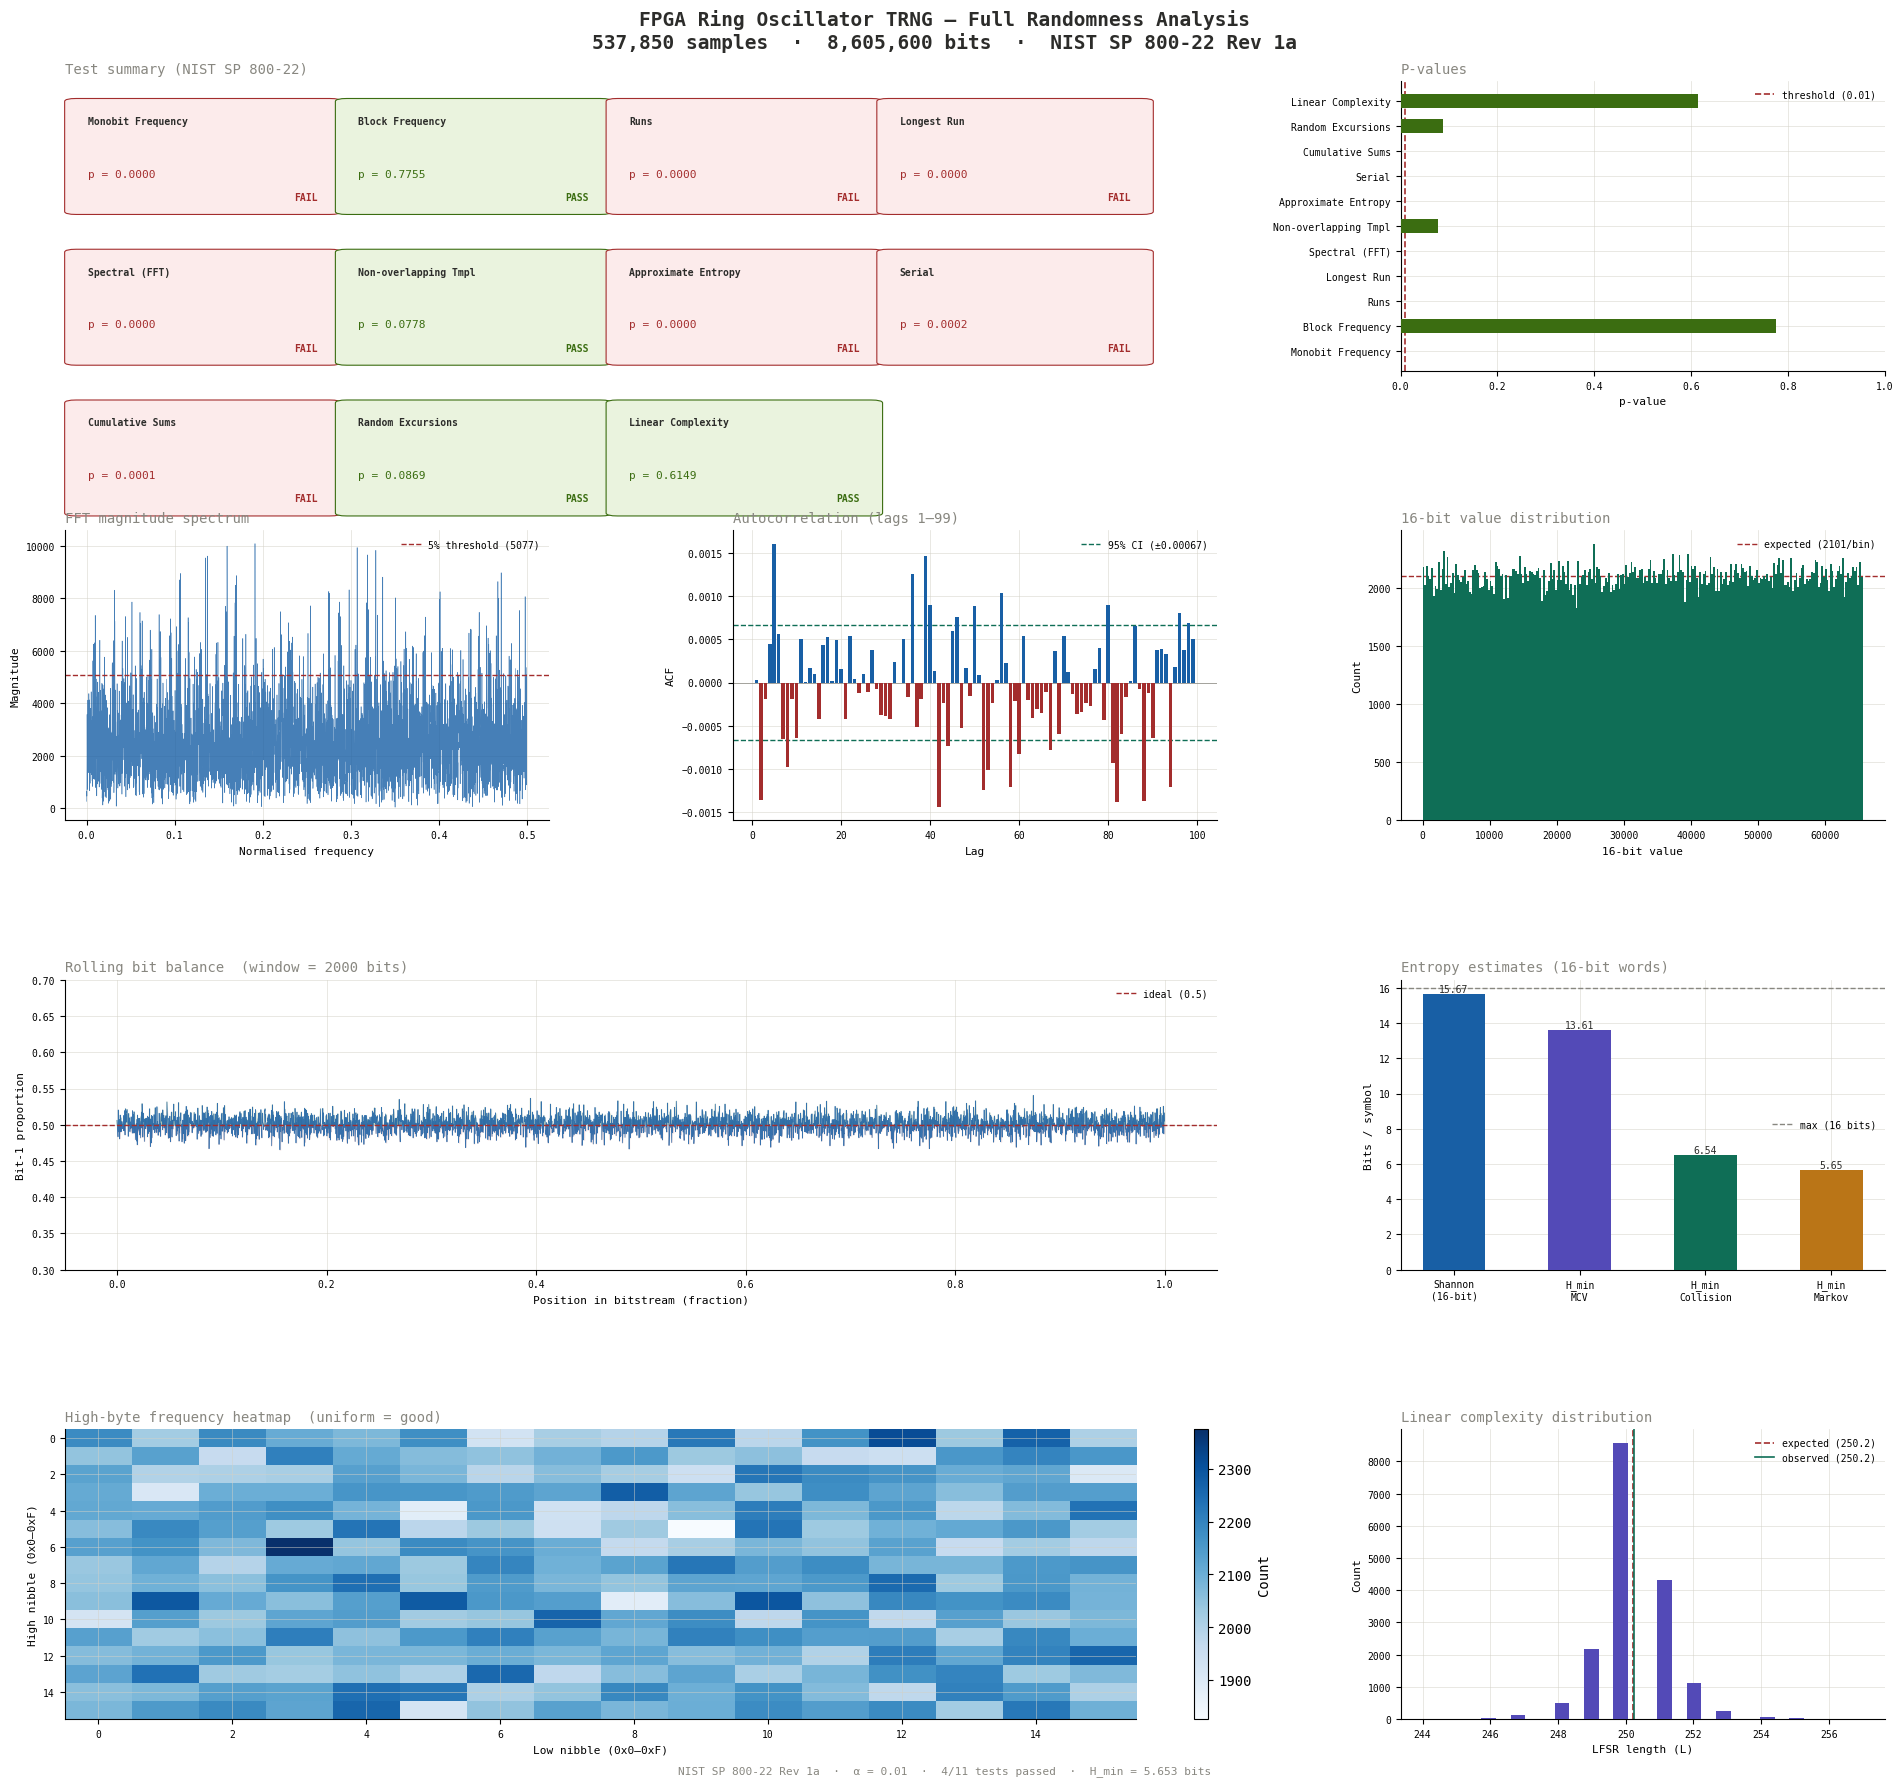

In [18]:
SAVE_PDF  = False
PDF_PATH  = CSV_PATH.replace(".csv", "_analysis.pdf")

fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    f"FPGA Ring Oscillator TRNG — Full Randomness Analysis\n"
    f"{n_samples:,} samples  ·  {n_bits:,} bits  ·  NIST SP 800-22 Rev 1a",
    fontsize=14, fontweight="bold", y=0.99, color="#2C2C2A"
)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38,
                       left=0.06, right=0.97, top=0.95, bottom=0.04)

# ── Panel 1: Summary cards ───────────────────────────────────────────────────
ax_sum = fig.add_subplot(gs[0, :2])
ax_sum.set_xlim(0, 1); ax_sum.set_ylim(0, 1); ax_sum.axis("off")
ax_sum.set_title("Test summary (NIST SP 800-22)", fontsize=10, color=MUTED, loc="left", pad=6)
n_cols = 4; card_w = 0.22; card_h = 0.38; gap_x = 0.015; gap_y = 0.14
start_x = 0.01; start_y = 0.55
for i, r in enumerate(results):
    col = i % n_cols; row = i // n_cols
    x   = start_x + col * (card_w + gap_x)
    y   = start_y - row * (card_h + gap_y)
    bg  = PASS_BG if r["passed"] else FAIL_BG
    fc  = PASS_COLOR if r["passed"] else FAIL_COLOR
    box = FancyBboxPatch((x, y), card_w, card_h,
                         boxstyle="round,pad=0.01", linewidth=0.8,
                         edgecolor=fc, facecolor=bg,
                         transform=ax_sum.transAxes, clip_on=False)
    ax_sum.add_patch(box)
    ax_sum.text(x+0.01, y+card_h-0.05, r["name"],
                fontsize=7, fontweight="bold", color="#2C2C2A",
                transform=ax_sum.transAxes, va="top")
    ax_sum.text(x+0.01, y+0.12, f"p = {r['p_value']:.4f}",
                fontsize=8, color=fc, transform=ax_sum.transAxes)
    ax_sum.text(x+card_w-0.01, y+0.04,
                "PASS" if r["passed"] else "FAIL",
                fontsize=7, fontweight="bold", color=fc,
                transform=ax_sum.transAxes, ha="right")

# ── Panel 2: P-value bar chart ───────────────────────────────────────────────
ax_pv = fig.add_subplot(gs[0, 2])
pvals  = [r["p_value"] for r in results]
bcolors = [PASS_COLOR if r["passed"] else FAIL_COLOR for r in results]
bars   = ax_pv.barh(range(len(results)), pvals, color=bcolors, height=0.55, zorder=3)
ax_pv.axvline(0.01, color=FAIL_COLOR, linewidth=1.2, linestyle="--", label="threshold (0.01)")
ax_pv.set_yticks(range(len(results)))
ax_pv.set_yticklabels([r["name"] for r in results], fontsize=7)
ax_pv.set_xlabel("p-value", fontsize=8)
ax_pv.set_title("P-values", fontsize=10, color=MUTED, loc="left", pad=6)
ax_pv.set_xlim(0, 1); ax_pv.legend(fontsize=7, frameon=False)
ax_pv.tick_params(labelsize=7)

# ── Panel 3: FFT magnitude spectrum ─────────────────────────────────────────
ax_fft = fig.add_subplot(gs[1, 0])
mags   = r_spectral["magnitudes"]
freqs  = np.arange(len(mags)) / n_bits
step   = max(1, len(freqs) // 4000)
ax_fft.plot(freqs[1::step], mags[1::step], color=ACCENT, linewidth=0.4, alpha=0.8)
ax_fft.axhline(r_spectral["threshold"], color=FAIL_COLOR, linewidth=1,
               linestyle="--", label=f"5% threshold ({r_spectral['threshold']:.0f})")
ax_fft.set_xlabel("Normalised frequency", fontsize=8)
ax_fft.set_ylabel("Magnitude", fontsize=8)
ax_fft.set_title("FFT magnitude spectrum", fontsize=10, color=MUTED, loc="left", pad=6)
ax_fft.legend(fontsize=7, frameon=False); ax_fft.tick_params(labelsize=7)

# ── Panel 4: Autocorrelation ─────────────────────────────────────────────────
ax_acf = fig.add_subplot(gs[1, 1])
lags   = np.arange(1, 100)
acf_v  = acf[1:100]
ci     = 1.96 / math.sqrt(n_bits)
ax_acf.bar(lags, acf_v,
           color=[ACCENT if v >= 0 else FAIL_COLOR for v in acf_v],
           width=0.8, zorder=3)
ax_acf.axhline( ci, color=TEAL, linewidth=1, linestyle="--", label=f"95% CI (±{ci:.5f})")
ax_acf.axhline(-ci, color=TEAL, linewidth=1, linestyle="--")
ax_acf.axhline(0,  color=MUTED, linewidth=0.5)
ax_acf.set_xlabel("Lag", fontsize=8); ax_acf.set_ylabel("ACF", fontsize=8)
ax_acf.set_title("Autocorrelation (lags 1–99)", fontsize=10, color=MUTED, loc="left", pad=6)
ax_acf.legend(fontsize=7, frameon=False); ax_acf.tick_params(labelsize=7)

# ── Panel 5: 16-bit value distribution ──────────────────────────────────────
ax_dist = fig.add_subplot(gs[1, 2])
ax_dist.hist(dec_values, bins=256, color=TEAL, edgecolor="none", zorder=3)
ax_dist.axhline(n_samples/256, color=FAIL_COLOR, linewidth=1, linestyle="--",
                label=f"expected ({n_samples/256:.0f}/bin)")
ax_dist.set_xlabel("16-bit value", fontsize=8)
ax_dist.set_ylabel("Count", fontsize=8)
ax_dist.set_title("16-bit value distribution", fontsize=10, color=MUTED, loc="left", pad=6)
ax_dist.legend(fontsize=7, frameon=False); ax_dist.tick_params(labelsize=7)

# ── Panel 6: Rolling bit balance ─────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[2, :2])
x_axis  = np.arange(n_win) * WINDOW / n_bits
ax_roll.plot(x_axis, rolling, color=ACCENT, linewidth=0.5, alpha=0.85)
ax_roll.axhline(0.5, color=FAIL_COLOR, linewidth=1, linestyle="--", label="ideal (0.5)")
ax_roll.fill_between(x_axis, rolling, 0.5,
                     where=rolling > 0.5, alpha=0.15, color=PASS_COLOR)
ax_roll.fill_between(x_axis, rolling, 0.5,
                     where=rolling < 0.5, alpha=0.15, color=FAIL_COLOR)
ax_roll.set_xlabel("Position in bitstream (fraction)", fontsize=8)
ax_roll.set_ylabel("Bit-1 proportion", fontsize=8)
ax_roll.set_ylim(0.3, 0.7)
ax_roll.set_title(f"Rolling bit balance  (window = {WINDOW} bits)",
                  fontsize=10, color=MUTED, loc="left", pad=6)
ax_roll.legend(fontsize=7, frameon=False); ax_roll.tick_params(labelsize=7)

# ── Panel 7: Entropy bar chart ───────────────────────────────────────────────
ax_ent = fig.add_subplot(gs[2, 2])
ent_labels = ["Shannon\n(16-bit)", "H_min\nMCV", "H_min\nCollision", "H_min\nMarkov"]
ent_vals   = [entropy_summary["shannon_16bit"], entropy_summary["h_mcv"],
              entropy_summary["h_collision"],   entropy_summary["h_markov"]]
ent_colors = [ACCENT, PURPLE, TEAL, AMBER]
bars_e = ax_ent.bar(ent_labels, ent_vals, color=ent_colors, zorder=3, width=0.5)
ax_ent.axhline(16.0, color=MUTED, linewidth=1, linestyle="--", label="max (16 bits)")
ax_ent.set_ylabel("Bits / symbol", fontsize=8)
ax_ent.set_title("Entropy estimates (16-bit words)", fontsize=10, color=MUTED, loc="left", pad=6)
ax_ent.legend(fontsize=7, frameon=False); ax_ent.tick_params(labelsize=7)
for bar, val in zip(bars_e, ent_vals):
    ax_ent.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f"{val:.2f}", ha="center", fontsize=7, color="#2C2C2A")

# ── Panel 8: Byte frequency heatmap ─────────────────────────────────────────
ax_heat = fig.add_subplot(gs[3, :2])
# Use high byte for a 16x16 heatmap
hm = byte_freq_hi.reshape(16, 16).astype(float)
im = ax_heat.imshow(hm, aspect="auto", cmap="Blues", interpolation="nearest")
plt.colorbar(im, ax=ax_heat, fraction=0.02, label="Count")
ax_heat.set_xlabel("Low nibble (0x0–0xF)", fontsize=8)
ax_heat.set_ylabel("High nibble (0x0–0xF)", fontsize=8)
ax_heat.set_title("High-byte frequency heatmap  (uniform = good)", fontsize=10, color=MUTED, loc="left", pad=6)
ax_heat.tick_params(labelsize=7)

# ── Panel 9: Linear complexity ───────────────────────────────────────────────
ax_lc = fig.add_subplot(gs[3, 2])
if r_lc and "complexities" in r_lc:
    ax_lc.hist(r_lc["complexities"], bins=30, color=PURPLE, edgecolor="none", zorder=3)
    ax_lc.axvline(r_lc["expected_complexity"], color=FAIL_COLOR, linewidth=1.2,
                  linestyle="--", label=f"expected ({r_lc['expected_complexity']:.1f})")
    ax_lc.axvline(r_lc["mean_complexity"], color=TEAL, linewidth=1.2,
                  label=f"observed ({r_lc['mean_complexity']:.1f})")
    ax_lc.set_xlabel("LFSR length (L)", fontsize=8)
    ax_lc.set_ylabel("Count", fontsize=8)
    ax_lc.set_title("Linear complexity distribution", fontsize=10, color=MUTED, loc="left", pad=6)
    ax_lc.legend(fontsize=7, frameon=False); ax_lc.tick_params(labelsize=7)
else:
    ax_lc.text(0.5, 0.5, "Linear Complexity\nskipped",
               ha="center", va="center", fontsize=9, color=MUTED,
               transform=ax_lc.transAxes)
    ax_lc.axis("off")

fig.text(0.5, 0.01,
         f"NIST SP 800-22 Rev 1a  ·  α = 0.01  ·  {passed}/{total} tests passed  ·  "
         f"H_min = {entropy_summary['h_min']:.3f} bits",
         ha="center", fontsize=8, color=MUTED)

if SAVE_PDF:
    plt.savefig(PDF_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved to: {PDF_PATH}")
else:
    plt.tight_layout()
    plt.show()


## 18 · Bitmap visualisation

Render a 512×512 tile of the bitstream as a grayscale image.  
True random data looks like TV static. Any visible structure (lines, gradients, patterns) = failure.


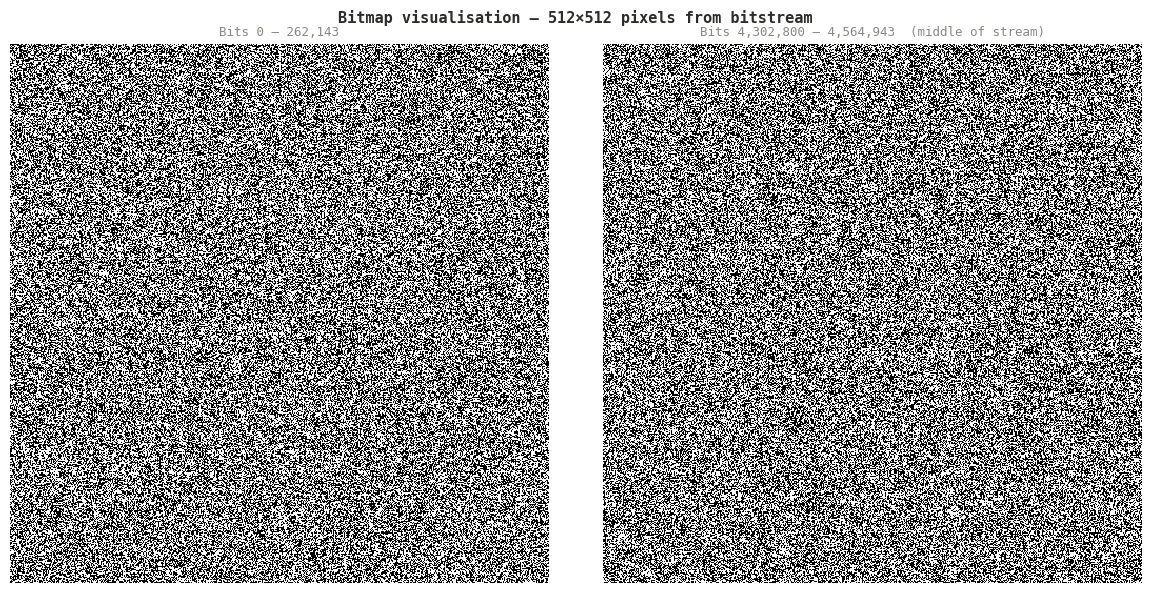

If either panel shows visible patterns, streaks, or gradients — investigate immediately.


In [19]:
fig_bm, axes_bm = plt.subplots(1, 2, figsize=(12, 6))
fig_bm.suptitle("Bitmap visualisation — 512×512 pixels from bitstream",
                fontsize=11, fontweight="bold", color="#2C2C2A")

# First 512×512 = 262144 bits → reshape to bytes then pixels
n_px = 512 * 512
px_bits = bits[:n_px].reshape(512, 512)
axes_bm[0].imshow(px_bits, cmap="gray", interpolation="nearest", aspect="equal")
axes_bm[0].set_title("Bits 0 – 262,143", fontsize=9, color=MUTED)
axes_bm[0].axis("off")

# Second tile: middle of the stream
mid = n_bits // 2
if mid + n_px <= n_bits:
    px_bits2 = bits[mid:mid+n_px].reshape(512, 512)
    axes_bm[1].imshow(px_bits2, cmap="gray", interpolation="nearest", aspect="equal")
    axes_bm[1].set_title(f"Bits {mid:,} – {mid+n_px-1:,}  (middle of stream)", fontsize=9, color=MUTED)
    axes_bm[1].axis("off")
else:
    axes_bm[1].text(0.5, 0.5, "Insufficient bits for second tile",
                    ha="center", va="center", color=MUTED, transform=axes_bm[1].transAxes)
    axes_bm[1].axis("off")

plt.tight_layout()
plt.show()
print("If either panel shows visible patterns, streaks, or gradients — investigate immediately.")


## 19 · Run length distribution

For truly random bits, run lengths follow a geometric distribution:  
P(run length = k) = (1/2)^k. Deviations reveal autocorrelation.


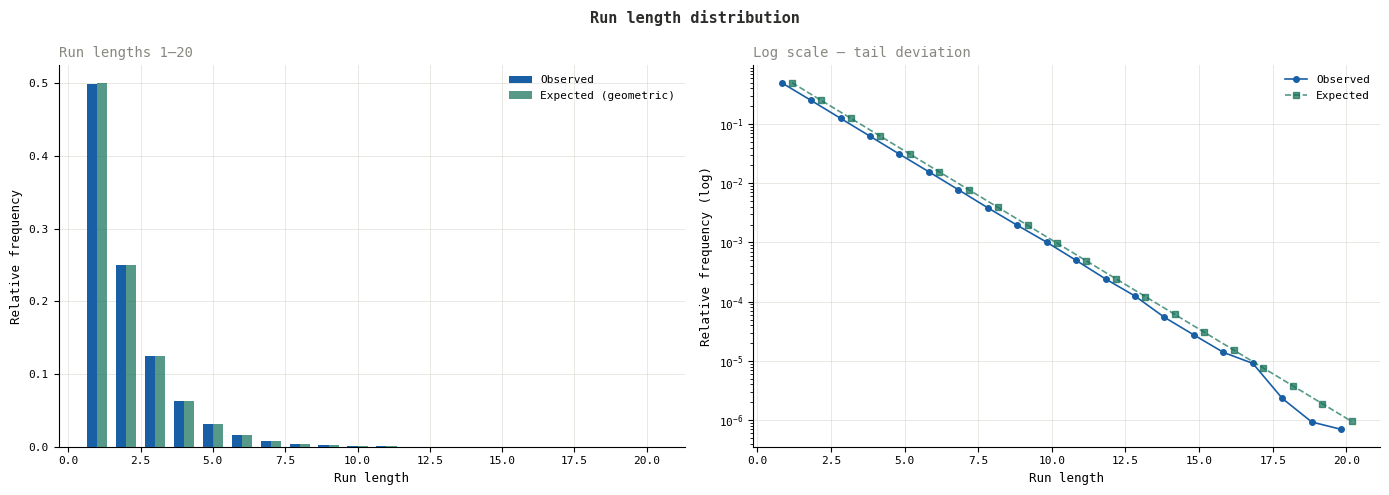

In [20]:
fig_rl, axes_rl = plt.subplots(1, 2, figsize=(14, 5))
fig_rl.suptitle("Run length distribution", fontsize=11, fontweight="bold", color="#2C2C2A")

max_shown = 20
observed_counts = np.bincount(run_lengths, minlength=max_shown+1)[:max_shown+1]
observed_freq   = observed_counts / observed_counts.sum()
expected_freq   = np.array([0.5**k for k in range(1, max_shown+2)])
expected_freq   = expected_freq / expected_freq.sum()

x = np.arange(1, max_shown+1)
w = 0.35
axes_rl[0].bar(x - w/2, observed_freq[1:max_shown+1], width=w, label="Observed", color=ACCENT, zorder=3)
axes_rl[0].bar(x + w/2, expected_freq[:max_shown],    width=w, label="Expected (geometric)", color=TEAL, alpha=0.7, zorder=3)
axes_rl[0].set_xlabel("Run length", fontsize=9)
axes_rl[0].set_ylabel("Relative frequency", fontsize=9)
axes_rl[0].set_title("Run lengths 1–20", fontsize=10, color=MUTED, loc="left")
axes_rl[0].legend(fontsize=8, frameon=False)
axes_rl[0].tick_params(labelsize=8)

# Log-scale to reveal tail
axes_rl[1].semilogy(x - w/2, observed_freq[1:max_shown+1] + 1e-10, 'o-',
                    label="Observed", color=ACCENT, linewidth=1.2, markersize=4)
axes_rl[1].semilogy(x + w/2, expected_freq[:max_shown] + 1e-10, 's--',
                    label="Expected", color=TEAL, linewidth=1.2, markersize=4, alpha=0.7)
axes_rl[1].set_xlabel("Run length", fontsize=9)
axes_rl[1].set_ylabel("Relative frequency (log)", fontsize=9)
axes_rl[1].set_title("Log scale — tail deviation", fontsize=10, color=MUTED, loc="left")
axes_rl[1].legend(fontsize=8, frameon=False)
axes_rl[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()


## 20 · Cumulative sum trajectory

Plots the forward and reverse random walk. A well-behaved TRNG stays near zero  
with no systematic drift. A ring oscillator with temperature-induced bias drift  
will show a visible slope in one direction over time.


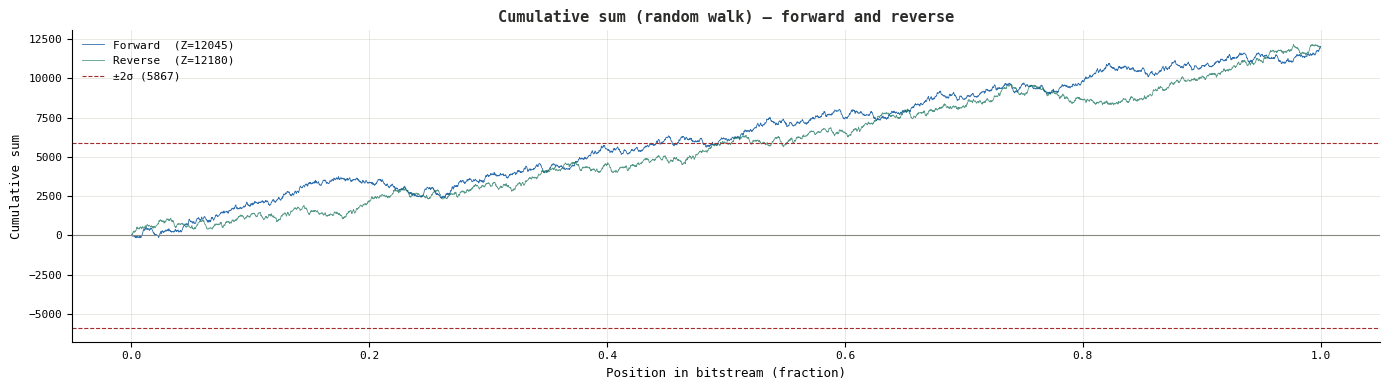

In [21]:
fig_cs, ax_cs = plt.subplots(figsize=(14, 4))
step_cs = max(1, len(r_cumsum["cumsum_fwd"]) // 5000)
x_cs    = np.arange(0, n_bits, step_cs) / n_bits
ax_cs.plot(x_cs, r_cumsum["cumsum_fwd"][::step_cs],
           color=ACCENT, linewidth=0.6, alpha=0.9, label=f"Forward  (Z={r_cumsum['z_fwd']:.0f})")
ax_cs.plot(x_cs, r_cumsum["cumsum_rev"][::step_cs],
           color=TEAL,  linewidth=0.6, alpha=0.7, label=f"Reverse  (Z={r_cumsum['z_rev']:.0f})")
ax_cs.axhline(0, color=MUTED, linewidth=0.8)
sigma_band = 2 * math.sqrt(n_bits)
ax_cs.axhline( sigma_band, color=FAIL_COLOR, linewidth=0.8, linestyle="--",
               label=f"±2σ ({sigma_band:.0f})")
ax_cs.axhline(-sigma_band, color=FAIL_COLOR, linewidth=0.8, linestyle="--")
ax_cs.set_xlabel("Position in bitstream (fraction)", fontsize=9)
ax_cs.set_ylabel("Cumulative sum", fontsize=9)
ax_cs.set_title("Cumulative sum (random walk) — forward and reverse",
                fontsize=11, fontweight="bold", color="#2C2C2A")
ax_cs.legend(fontsize=8, frameon=False)
ax_cs.tick_params(labelsize=8)
plt.tight_layout()
plt.show()


## 21 · Optional — individual test detail plots

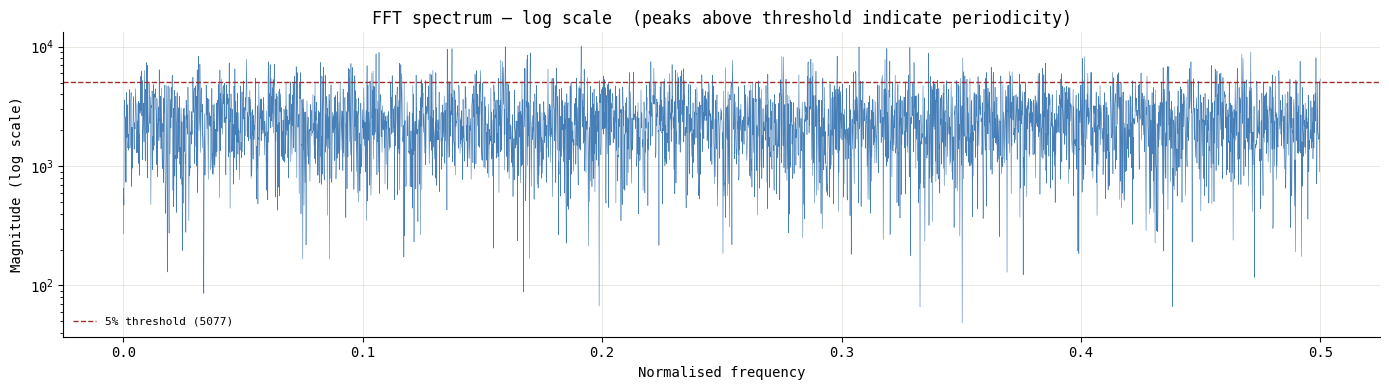

In [22]:
# Spectral — log-scale view to reveal subtle peaks
fig2, ax = plt.subplots(figsize=(14, 4))
mags = r_spectral["magnitudes"]
freqs = np.arange(len(mags)) / n_bits
step  = max(1, len(freqs) // 4000)
ax.semilogy(freqs[1::step], mags[1::step], color=ACCENT, linewidth=0.4, alpha=0.8)
ax.axhline(r_spectral["threshold"], color=FAIL_COLOR, linewidth=1,
           linestyle="--", label=f"5% threshold ({r_spectral['threshold']:.0f})")
ax.set_xlabel("Normalised frequency"); ax.set_ylabel("Magnitude (log scale)")
ax.set_title("FFT spectrum — log scale  (peaks above threshold indicate periodicity)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()


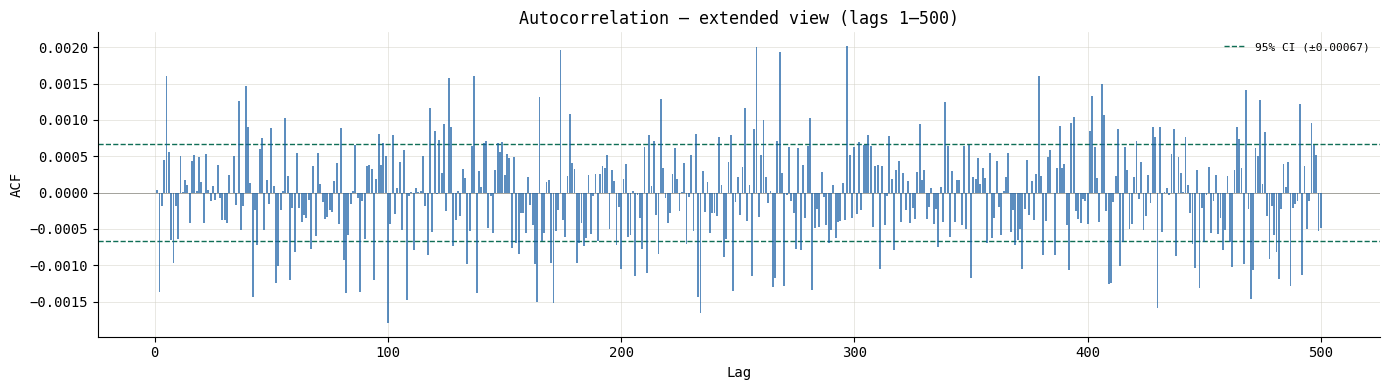

In [23]:
# Autocorrelation — extended to 500 lags
fig3, ax = plt.subplots(figsize=(14, 4))
acf_ext = acf_raw[:501] / acf_raw[0]
lags_ext = np.arange(1, 501)
ax.bar(lags_ext, acf_ext[1:], color=ACCENT, width=0.8, alpha=0.7, zorder=3)
ci = 1.96 / math.sqrt(n_bits)
ax.axhline( ci, color=TEAL, linewidth=1, linestyle="--", label=f"95% CI (±{ci:.5f})")
ax.axhline(-ci, color=TEAL, linewidth=1, linestyle="--")
ax.axhline(0,   color=MUTED, linewidth=0.5)
ax.set_xlabel("Lag"); ax.set_ylabel("ACF")
ax.set_title("Autocorrelation — extended view (lags 1–500)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()


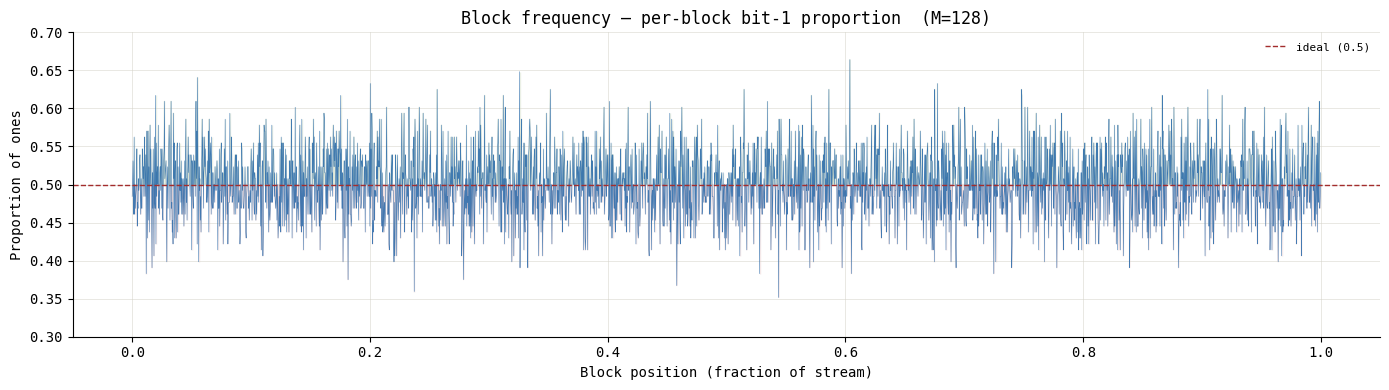

In [24]:
# Block frequency — block-by-block proportion plot
fig4, ax = plt.subplots(figsize=(14, 4))
pi_i = r_block["pi_blocks"]
x4   = np.arange(len(pi_i)) / len(pi_i)
step4 = max(1, len(pi_i) // 3000)
ax.plot(x4[::step4], pi_i[::step4], color=ACCENT, linewidth=0.4, alpha=0.8)
ax.axhline(0.5, color=FAIL_COLOR, linewidth=1, linestyle="--", label="ideal (0.5)")
ax.fill_between(x4[::step4], pi_i[::step4], 0.5,
                where=pi_i[::step4]>0.5, alpha=0.1, color=PASS_COLOR)
ax.fill_between(x4[::step4], pi_i[::step4], 0.5,
                where=pi_i[::step4]<0.5, alpha=0.1, color=FAIL_COLOR)
ax.set_ylim(0.3, 0.7)
ax.set_xlabel("Block position (fraction of stream)")
ax.set_ylabel("Proportion of ones")
ax.set_title(f"Block frequency — per-block bit-1 proportion  (M={r_block['M']})")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()


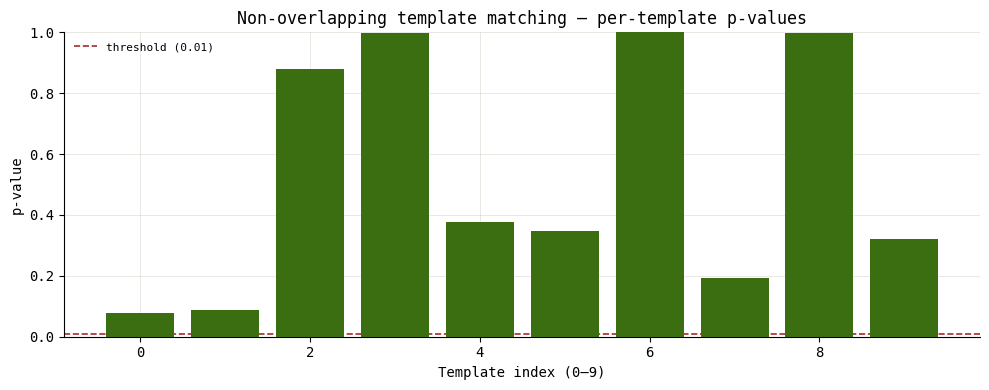

In [25]:
# Non-overlapping template — per-template p-values
if "all_p" in r_not:
    fig5, ax = plt.subplots(figsize=(10, 4))
    pv_list = r_not["all_p"]
    colors5  = [PASS_COLOR if p >= 0.01 else FAIL_COLOR for p in pv_list]
    ax.bar(range(len(pv_list)), pv_list, color=colors5, zorder=3)
    ax.axhline(0.01, color=FAIL_COLOR, linewidth=1.2, linestyle="--", label="threshold (0.01)")
    ax.set_xlabel("Template index (0–9)")
    ax.set_ylabel("p-value")
    ax.set_title("Non-overlapping template matching — per-template p-values")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, frameon=False)
    plt.tight_layout(); plt.show()
